<h1>Train — DenseNet-121</h1>

Trains and evaluates DenseNet-121 using the tuned hyperparameters from `ARCH_HYPERPARAMS["densenet121"]`, then saves its results and weights to disk for the results notebook.

In [1]:
from wwtw_utils import *

Using device: cuda
Test set ID (derived from DATASET_ROOT): Waterval
Train-time augmentation: on
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 709 | Val: 170 | Test: 864


## Build dataloaders + class weights for this architecture

In [2]:
cfg = ARCH_HYPERPARAMS["densenet121"]

# The tuned batch size (cfg["batch_size"]) can be too large to fit in GPU
# memory for a deeper model like this one, even though it fit fine for
# whichever model the tuning trials actually ran on. Rather than hard-coding
# a smaller batch size (and drifting from the tuned hyperparameters), cap the
# *actual* loader batch size at MICRO_BATCH_CAP and use gradient accumulation
# in train_model to still reach the tuned effective batch size.
micro_batch = min(cfg["batch_size"], MICRO_BATCH_CAP)
accum_steps = max(1, round(cfg["batch_size"] / micro_batch))
print(f"DenseNet-121: micro batch = {micro_batch}, accumulation steps = {accum_steps} "
      f"(effective batch size ≈ {micro_batch * accum_steps}, tuned value = {cfg['batch_size']})")

# This backbone gets its own dataloaders — its own (capped) batch size, and
# (for InceptionNet v3) its own image size.
train_ds_arch, val_ds_arch, test_ds_arch, train_loader_arch, val_loader_arch, test_loader_arch = \
    get_dataloaders(cfg["img_size"], micro_batch)

class_weights_arch = make_class_weights(train_ds_arch)

DenseNet-121: micro batch = 8, accumulation steps = 1 (effective batch size ≈ 8, tuned value = 8)


## Define the model

In [3]:
# ---------------------------------------------------------
# Define the CNN (Transfer Learning with DenseNet-121)
# ---------------------------------------------------------
model = models.densenet121(weights=models.DenseNet121_Weights.IMAGENET1K_V1)
in_f = model.classifier.in_features
model.classifier = build_classifier_head(in_f, cfg["hidden_layers"], cfg["neurons"], num_classes)

model = model.to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights_arch)
optimizer = optim.Adam(
    model.parameters(),
    lr=cfg["lr"],
    betas=(cfg["beta1"], ADAM_BETA2),
    weight_decay=WEIGHT_DECAY,
)
# Step-based decay: LR x0.1 every Es epochs, per the Bayesian-optimized step size.
scheduler = StepLR(optimizer, step_size=cfg["step_size"], gamma=0.1)

## Train, then plot training curves

[DenseNet-121] Epoch   1/100 | LR: 3.16e-04 | train loss 1.0640 acc 0.568 | val loss 0.6566 acc 0.735 *


[DenseNet-121] Epoch   2/100 | LR: 3.16e-04 | train loss 0.9530 acc 0.646 | val loss 0.6250 acc 0.729 *


[DenseNet-121] Epoch   3/100 | LR: 3.16e-04 | train loss 0.8761 acc 0.709 | val loss 1.0017 acc 0.600


[DenseNet-121] Epoch   4/100 | LR: 3.16e-04 | train loss 0.8522 acc 0.688 | val loss 0.8969 acc 0.624


[DenseNet-121] Epoch   5/100 | LR: 3.16e-04 | train loss 0.8060 acc 0.721 | val loss 0.5361 acc 0.753 *


...

[DenseNet-121] Epoch  28/100 | LR: 3.16e-05 | train loss 0.3262 acc 0.884 | val loss 0.4311 acc 0.788


[DenseNet-121] Epoch  29/100 | LR: 3.16e-05 | train loss 0.3291 acc 0.886 | val loss 0.4417 acc 0.788


[DenseNet-121] Epoch  30/100 | LR: 3.16e-05 | train loss 0.3385 acc 0.890 | val loss 0.4349 acc 0.800


[DenseNet-121] Epoch  31/100 | LR: 3.16e-05 | train loss 0.3071 acc 0.891 | val loss 0.5115 acc 0.771


[DenseNet-121] Epoch  32/100 | LR: 3.16e-05 | train loss 0.3052 acc 0.897 | val loss 0.5245 acc 0.747

[DenseNet-121] No val loss improvement for 10 epochs — stopping early at epoch 32.

[DenseNet-121] Restored best checkpoint (val loss = 0.4180)


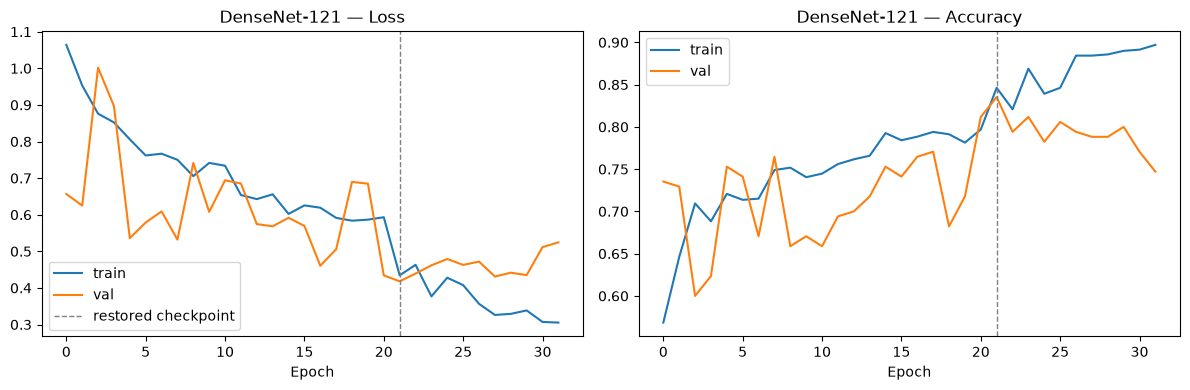

In [4]:
history = train_model(
    model, train_loader_arch, val_loader_arch, optimizer, scheduler,
    criterion, EPOCHS, EARLY_STOP_PATIENCE, "DenseNet-121", is_inception=False,
    accum_steps=accum_steps,
)
plot_training_curves(history, "DenseNet-121")

## Evaluate on the test set

[DenseNet-121] Test accuracy: 0.747


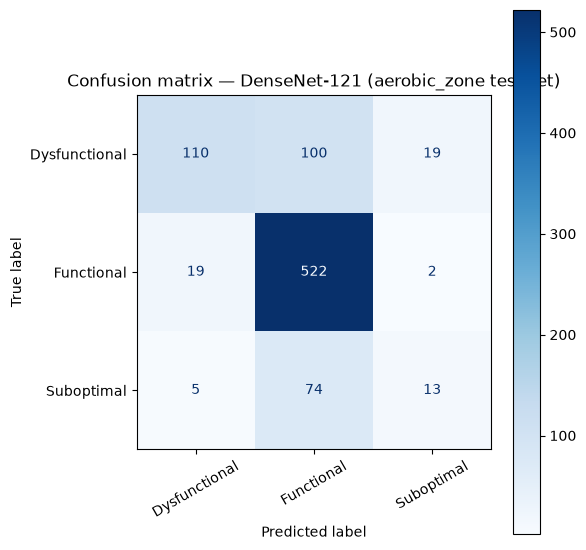

               precision    recall  f1-score   support

Dysfunctional      0.821     0.480     0.606       229
   Functional      0.750     0.961     0.843       543
   Suboptimal      0.382     0.141     0.206        92

     accuracy                          0.747       864
    macro avg      0.651     0.528     0.552       864
 weighted avg      0.730     0.747     0.712       864



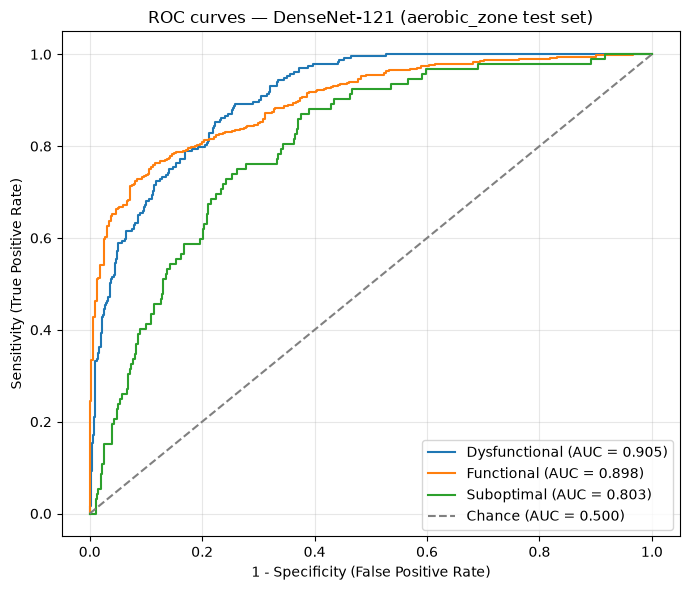

AUC (area under ROC curve) per class:
  Dysfunctional  : 0.905
  Functional     : 0.898
  Suboptimal     : 0.803

Mean AUC (over 3/3 classes with test examples): 0.869


(np.float64(0.7465277777777778),
 {'Dysfunctional': 0.9052367362376645,
  'Functional': 0.8978445580397354,
  'Suboptimal': 0.8031651272809192})

In [5]:
evaluate_and_record(
    model, test_loader_arch, "DenseNet-121", history,
    img_size=cfg["img_size"], hidden_layers=cfg["hidden_layers"], neurons=cfg["neurons"],
)

## Save results + model weights to disk

In [6]:
save_result("DenseNet-121", "densenet121")

Saved results to ../results/aerobic_zone_aug/results_aerobic_zone_densenet121_Waterval.pkl
Saved model weights to ../models/aerobic_zone_densenet121_cnn.pt
